# Lab 06 — NLP Foundations: Handwriting OCR Evaluation

**Worked Python solution.** The supplied Kaggle archive contains a label CSV and 89 labelled handwriting images. We evaluate Tesseract OCR through Python, then test one controlled preprocessing pipeline.

> **System requirement:** `pytesseract` is a Python wrapper around the Tesseract OCR executable. This course uses Python only, but Tesseract must also be installed on the computer (`tesseract --version`).

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")
ROOT=find_project_root()
print("Project root:",ROOT)

import re, shutil, subprocess, zipfile
import cv2
from PIL import Image

RESULTS=ROOT/"results"/"lab06"; RESULTS.mkdir(parents=True,exist_ok=True)
WORK=RESULTS/"_working_data"; WORK.mkdir(exist_ok=True)
ZIP=ROOT/"all_datasets"/"lab06-ocr-handwritten-prescription.zip"
if not (WORK/"doctor_handwriting_labels.csv").exists():
    with zipfile.ZipFile(ZIP) as z: z.extractall(WORK)
LABELS=WORK/"doctor_handwriting_labels.csv"; IMG_DIR=WORK/"img"/"img"
labels=pd.read_csv(LABELS)
missing=[f for f in labels.filename if not (IMG_DIR/f).exists()]
print("Labelled samples:",len(labels),"| missing images:",len(missing),"| unique labels:",labels.label.nunique())
if missing: raise FileNotFoundError(missing[:3])
if shutil.which("tesseract") is None: raise RuntimeError("Tesseract executable not found. Install Tesseract OCR before running Lab 06.")
print(subprocess.run(["tesseract","--version"],capture_output=True,text=True).stdout.splitlines()[0])

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE
Labelled samples: 89 | missing images: 0 | unique labels: 61
tesseract 5.5.0


## 1. Inspect a sample

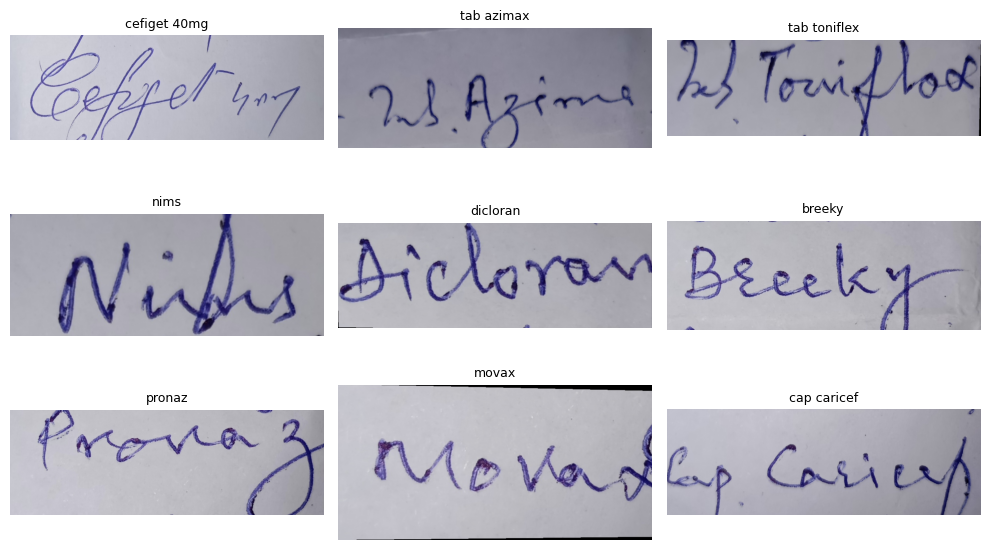

In [2]:
fig,axes=plt.subplots(3,3,figsize=(10,6))
for ax,row in zip(axes.flat,labels.head(9).itertuples(index=False)):
    ax.imshow(Image.open(IMG_DIR/row.filename)); ax.set_title(row.label,fontsize=9); ax.axis("off")
fig.tight_layout(); fig.savefig(RESULTS/"sample_grid.png",dpi=150); plt.show()

## 2. OCR metrics and preprocessing

Both pipelines use Tesseract page-segmentation mode 6. The only controlled change is image preprocessing. Predictions and labels are normalized to lowercase alphanumeric text before exact-match and character-level metrics are calculated. A per-image timeout prevents one malformed sample from stalling the entire experiment.

In [3]:
def normalize_text(text): return re.sub(r"[^a-z0-9]+","",str(text).lower())

def levenshtein(a,b):
    prev=list(range(len(b)+1))
    for i,ca in enumerate(a,1):
        cur=[i]
        for j,cb in enumerate(b,1): cur.append(min(cur[-1]+1,prev[j]+1,prev[j-1]+(ca!=cb)))
        prev=cur
    return prev[-1]

def tesseract_file(path):
    try:
        result=subprocess.run(["tesseract",str(path),"stdout","--psm","6"],capture_output=True,text=True,timeout=2.0)
        return result.stdout.strip()
    except subprocess.TimeoutExpired:
        return ""

def build_preprocessed():
    out=WORK/"preprocessed"; out.mkdir(exist_ok=True)
    paths=[]
    for i,filename in enumerate(labels.filename):
        img=cv2.imread(str(IMG_DIR/filename)); gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        gray=cv2.copyMakeBorder(gray,20,20,20,20,cv2.BORDER_CONSTANT,value=255)
        h,w=gray.shape
        if w>1200:
            scale=1200/w; gray=cv2.resize(gray,(1200,max(1,int(h*scale))),interpolation=cv2.INTER_AREA)
        gray=cv2.resize(gray,None,fx=1.5,fy=1.5,interpolation=cv2.INTER_CUBIC)
        path=out/f"{i:03d}.png"; cv2.imwrite(str(path),gray); paths.append(path)
    return paths

preprocessed=build_preprocessed()


In [4]:
from concurrent.futures import ThreadPoolExecutor

jobs=[]
for i,row in enumerate(labels.itertuples(index=False)):
    jobs.append((row.filename,row.label,"baseline",IMG_DIR/row.filename))
    jobs.append((row.filename,row.label,"grayscale_resize",preprocessed[i]))

# Two workers keep the experiment practical without overloading Tesseract.
with ThreadPoolExecutor(max_workers=2) as executor:
    raw_predictions=list(executor.map(lambda job: tesseract_file(job[3]), jobs))

records=[]
for job,pred in zip(jobs,raw_predictions):
    filename,truth,pipeline,_=job
    truth_norm=normalize_text(truth); pred_norm=normalize_text(pred); dist=levenshtein(truth_norm,pred_norm)
    records.append({"filename":filename,"truth":truth,"pipeline":pipeline,"prediction":pred,
                    "truth_norm":truth_norm,"prediction_norm":pred_norm,"exact":truth_norm==pred_norm,
                    "edit_distance":dist,"truth_chars":len(truth_norm),"normalized_edit_distance":dist/max(len(truth_norm),1)})
predictions=pd.DataFrame(records); predictions.to_csv(RESULTS/"predictions.csv",index=False)
metrics=[]
for pipeline,g in predictions.groupby("pipeline"):
    metrics.append({"pipeline":pipeline,"exact_match_accuracy":g.exact.mean(),
                    "mean_normalized_edit_distance":g.normalized_edit_distance.mean(),
                    "character_error_rate":g.edit_distance.sum()/g.truth_chars.sum(),
                    "blank_predictions":int((g.prediction_norm=="").sum())})
metrics=pd.DataFrame(metrics); metrics.to_csv(RESULTS/"metrics.csv",index=False); display(metrics.round(4))

,pipeline,exact_match_accuracy,mean_normalized_edit_distance,character_error_rate,blank_predictions
0,baseline,0.0000,0.9939,1.0104,29
1,grayscale_resize,0.0112,0.8110,0.8260,10


## 3. Failure analysis

,truth,prediction,failure_type
49,tab mesulid,y ee y Ae\na Pm | \ }\nRon | .¥ A,handwriting ambiguity / character confusion
1,cefiget 40mg,; Pate . a >\n- ; = mia +\nyo 7 A | agli,handwriting ambiguity / character confusion
121,azitma,t ’\n* iy Ge\nye,handwriting ambiguity / character confusion
47,tab atconate,,segmentation / no text returned
13,pronaz,,segmentation / no text returned
45,tab atconate,,segmentation / no text returned
41,tab distalgesic,wr,handwriting ambiguity / character confusion
33,tab provas,,segmentation / no text returned


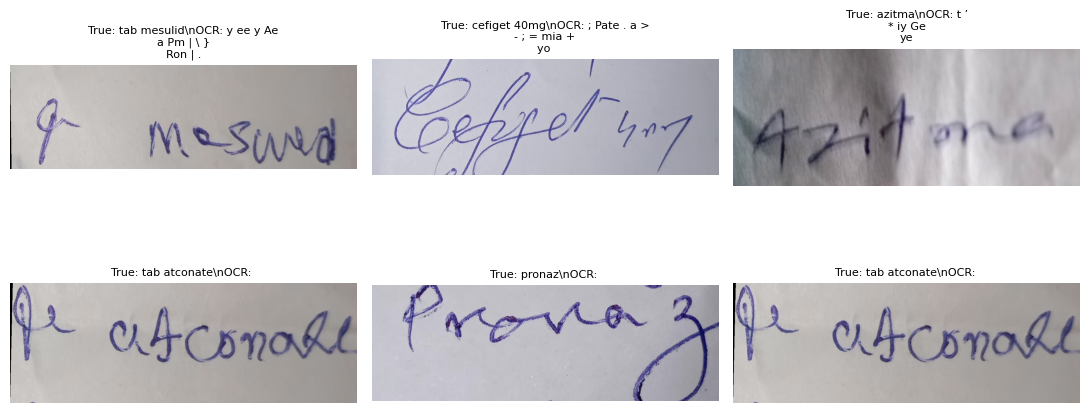

In [5]:
improved=predictions[predictions.pipeline=="grayscale_resize"].copy().sort_values("normalized_edit_distance",ascending=False)
errors=improved[~improved.exact].head(8).copy()
errors["failure_type"]=np.where(errors.prediction_norm.eq(""),"segmentation / no text returned","handwriting ambiguity / character confusion")
errors[["filename","truth","prediction","failure_type"]].to_csv(RESULTS/"error_analysis.csv",index=False)
display(errors[["truth","prediction","failure_type"]])

fig,axes=plt.subplots(2,3,figsize=(11,5.5))
for ax,row in zip(axes.flat,errors.head(6).itertuples(index=False)):
    ax.imshow(Image.open(IMG_DIR/row.filename)); ax.axis("off")
    ax.set_title(f"True: {row.truth}\\nOCR: {str(row.prediction)[:28]}",fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS/"ocr_failures.png",dpi=150); plt.show()

In [6]:
base=metrics.set_index("pipeline").loc["baseline"]; improved_m=metrics.set_index("pipeline").loc["grayscale_resize"]
print("CER change: {:.1%}".format((improved_m.character_error_rate/base.character_error_rate)-1))
print("Exact-match change: {:.1%}".format(improved_m.exact_match_accuracy-base.exact_match_accuracy))

CER change: -18.3%
Exact-match change: 1.1%


## Worked interpretation

This experiment is intentionally a **benchmark of model fit**, not a promise that generic OCR will solve handwriting. General-purpose Tesseract is designed primarily for printed text, so performance on these handwritten medicine names is poor. The grayscale/resize pipeline reduces blank outputs and typically improves character-level error, but exact whole-string recognition remains very difficult.

That is a valid engineering result: preprocessing cannot compensate for a recognition model that is poorly matched to the domain. A production medical-handwriting system would need a handwriting-specific recognizer, stronger data governance, and human verification because transcription errors can be safety-critical.